# Exploratory Data Analysis — the product catalog

A descriptive look at the catalog both models are built on: the image **classifier** (which predicts a product's subcategory from its photo) and the **recommender** (which ranks similar products). The aim here is to understand the catalog's composition — its categories, attributes, and images — well enough to justify the modeling choices that follow.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / 'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.recommender import load_catalog

df = load_catalog()
f"{len(df):,} products | {df.subCategory.nunique()} subCategories | "
f"{df.articleType.nunique()} articleTypes | {df.gender.nunique()} genders"

'115 articleTypes | 5 genders'

In [2]:
df[['productDisplayName', 'subCategory', 'articleType', 'gender', 'baseColour', 'season', 'usage']].head()

,productDisplayName,subCategory,articleType,gender,baseColour,season,usage
0,Turtle Check Men Navy Blue Shirt,Topwear,Shirts,Men,Navy Blue,Fall,Casual
1,Peter England Men Party Blue Jeans,Bottomwear,Jeans,Men,Blue,Summer,Casual
2,Titan Women Silver Watch,Watches,Watches,Women,Silver,Winter,Casual
3,Manchester United Men Solid Black Track Pants,Bottomwear,Track Pants,Men,Black,Fall,Casual
4,Puma Men Grey T-shirt,Topwear,Tshirts,Men,Grey,Summer,Casual


## 1. Category structure

The classifier's target is `subCategory`; the recommender ranks within and across these categories. Two grains matter — the coarse `subCategory` (the model target) and the finer `articleType`.

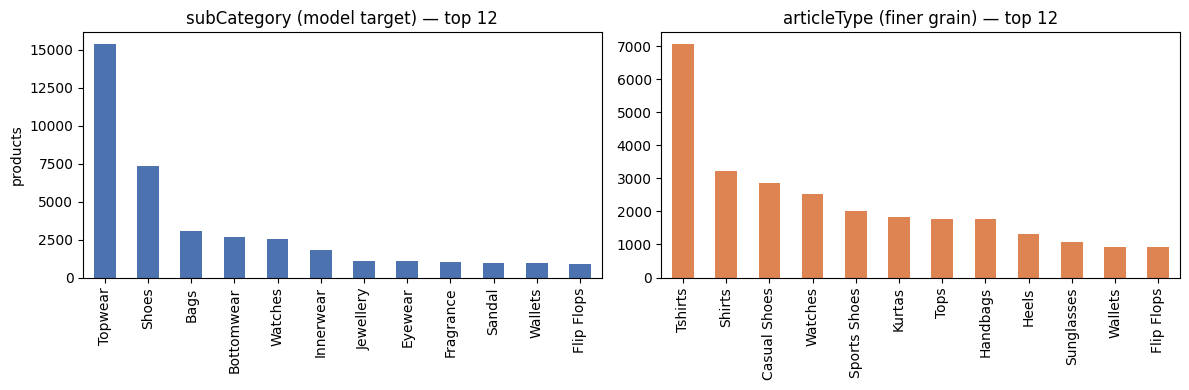

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df.subCategory.value_counts().head(12).plot.bar(ax=axes[0], color='#4C72B0')
axes[0].set_title('subCategory (model target) — top 12'); axes[0].set_ylabel('products')
df.articleType.value_counts().head(12).plot.bar(ax=axes[1], color='#DD8452')
axes[1].set_title('articleType (finer grain) — top 12')
for ax in axes:
    ax.set_xlabel('')
plt.tight_layout()

The catalog is strongly head-dominated: a few subcategories (Topwear, Shoes, Bags…) hold most of the volume, with a long tail of rare ones. This shapes both models:

- **Classifier** — the imbalance is why training uses a class-weighted loss and why subcategories below a minimum count are dropped (Section 5), so rare classes don't destabilize learning or evaluation.
- **Recommender** — a popularity baseline simply returns the most common article types within a category, so it looks the same for *every* query in that category. That uniformity is the gap a query-aware model has to close.

## 2. Structured attributes

Beyond the photo, each product carries four structured attributes — `gender`, `baseColour`, `season`, `usage` — which the recommender uses as ranking boosts on top of the photo-derived category.

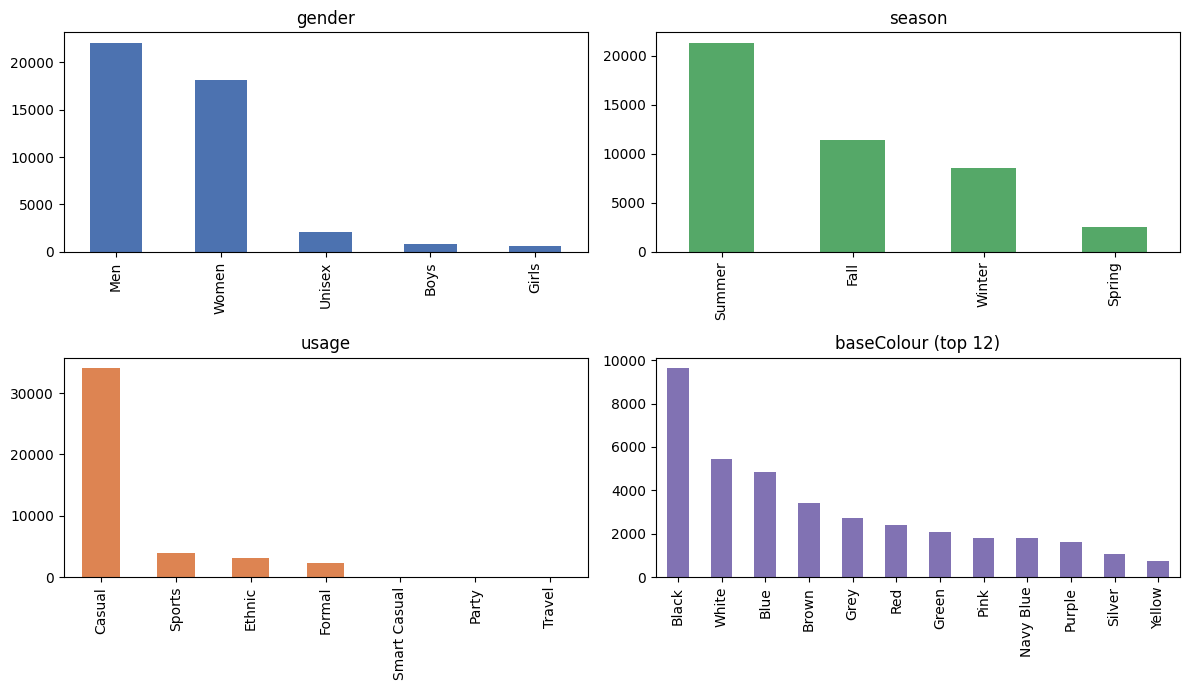

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
df.gender.value_counts().plot.bar(ax=axes[0, 0], color='#4C72B0', title='gender')
df.season.value_counts().plot.bar(ax=axes[0, 1], color='#55A868', title='season')
df.usage.value_counts().plot.bar(ax=axes[1, 0], color='#DD8452', title='usage')
df.baseColour.value_counts().head(12).plot.bar(ax=axes[1, 1], color='#8172B3', title='baseColour (top 12)')
for ax in axes.ravel():
    ax.set_xlabel('')
plt.tight_layout()

Each attribute is itself imbalanced (e.g. a few colours and the *Casual* usage dominate), which limits how much discriminating signal any single attribute can carry — a point the next section quantifies.

## 3. How strongly do attributes relate to category?

The recommender reads a product's category from its photo and uses an attribute (`gender`) as a ranking boost. How much does each structured attribute actually pin down `subCategory`? Cramér's V measures the association between each attribute and the category (0 = none, 1 = perfect).

In [5]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    cm = pd.crosstab(x, y).to_numpy()
    chi2 = chi2_contingency(cm)[0]
    n = cm.sum(); r, k = cm.shape
    return np.sqrt((chi2 / n) / (min(r, k) - 1))

pd.Series(
    {c: round(cramers_v(df[c], df.subCategory), 3) for c in ['gender', 'baseColour', 'season', 'usage']},
    name="Cramer's V vs subCategory",
).sort_values(ascending=False)

season        0.641
gender        0.307
usage         0.278
baseColour    0.223
Name: Cramer's V vs subCategory, dtype: float64

All four attributes are associated with subcategory to differing degrees — `season` shows the strongest link and `baseColour` the weakest — but even the strongest overlaps heavily with what the photo already reveals about a product's category. So the recommender reads category from the image classifier and uses the attributes only as light boosts, rather than relying on them to identify the category.

## 4. Product images

The source photos are portrait (~60×80). The classifier resizes them to 80×80 squares — small enough to train a CNN quickly, large enough to carry the coarse-category signal the recommender needs.

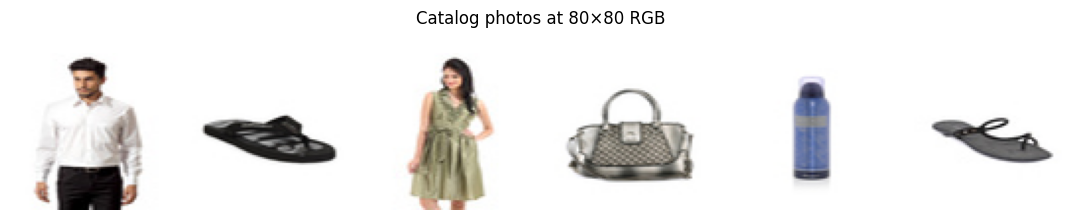

In [6]:
from src.data import IMAGES_CACHE, IMG_SIZE

imgs = np.load(IMAGES_CACHE)
rng = np.random.default_rng(7)
fig, axes = plt.subplots(1, 6, figsize=(11, 2.2))
for ax, i in zip(axes, rng.integers(0, len(imgs), 6)):
    ax.imshow(imgs[i]); ax.axis('off')
fig.suptitle(f'Catalog photos at {IMG_SIZE}×{IMG_SIZE} RGB')
plt.tight_layout()

## 5. Data preparation decisions (`src/data.py`)

The transforms the rest of the project depends on, and the reasoning behind each:

- **Resize to 80×80 RGB.** Squares the portrait photos with minimal distortion while keeping training fast; the coarse subcategory does not need full resolution.
- **Drop subcategories under 100 samples.** Removes 18 long-tail classes too sparse to learn or evaluate, leaving a **27-subcategory** universe shared by the classifier and the recommender.
- **Drop rows missing a required field** (target or any structured attribute), so every retained row is fully usable.
- **Fixed split seed (42)** for the stratified 70/15/15 partition, so model seeds vary the architecture's randomness, never the train/test split.

In [7]:
vc = df.subCategory.value_counts()
print(f"Subcategories kept: {vc.size}")
print(f"Smallest kept subcategory: {vc.idxmin()} ({vc.min()} products — at or above the 100-sample cutoff)")

Subcategories kept: 27
Smallest kept subcategory: Free Gifts (104 products — at or above the 100-sample cutoff)
